## Stochastic logistic growth process:

$$
    x_t = x_{t-1} + r\, x_{t-1}\!\left(1 - \frac{x_{t-1}}{k}\right) +
    x_{t-1}\,\varepsilon_t, \quad \varepsilon_t \sim
    \mathcal{N}(0,\sigma^2_{\mathrm{log}}),
$$

with parameters $r = 0.22$, $k = 10$, $\sigma_{\mathrm{log}} = 0.18$,
initial condition $x_0 = 0.8$, and time horizon $T = 50$.

We evaluate the following past LTL property, which combines a safety condition
over the first part of the trajectory with a safety condition over the
final steps:
$$
    \varphi_{\mathrm{log}} = H_{[10,5
    0]}(x < k) \wedge H_{[0,10]}(x > k).
$$

In [8]:
import torch
from torch.nn.functional import threshold
import numpy as np

from models import ou_model, logistic_model, simulate, plot_traj_set

1) Monte Carlo simulations

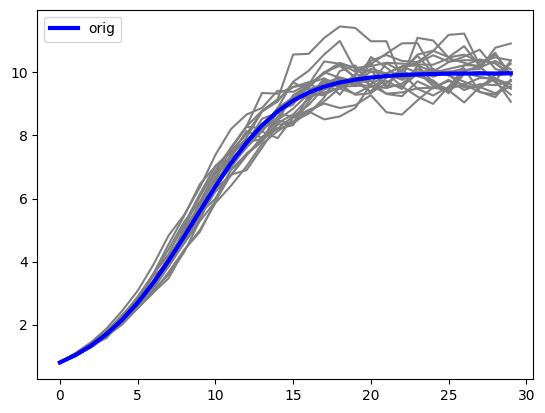

In [9]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time_steps = 30

#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.8,  # initial x
            'r': 0.32,        #
            'k': 10.0,        #
            'sigma': 0.18}



trajs = simulate(logistic_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

In [10]:
t = 20

pre = torch.prod(trajs[:,:t]<10.0, dim=1)
post = trajs[:,t] >= 10.0
reach = pre * post
reach.float().mean()


tensor(0.1123)

In [11]:
thr = 10.5
reach = torch.max(trajs, dim=1).values  > thr
p_ev = reach.float().mean()
print("eventually reach",p_ev)




eventually reach tensor(0.4905)


In [12]:
# sometimes[0,b] historically |x - 10|  <= 1
threshold = 10
reach_int  = 1.0
#aromic proposition
atom = (torch.abs(trajs - threshold) <= reach_int).int()

# historically [t,T] atom same as globally atom
historically = torch.flip(torch.cumprod(torch.flip(atom, dims=[1]), dim=1), dims=[1])
#eventually[0,b]  globally atom
sometimes = torch.cummax(historically, dim=1).values

truth_probability = sometimes.float().mean(dim=0)
#b = 30
truth_probability[29]

tensor(0.9763)

In [15]:
# compute the same probability using the trajectories trajs
trajs_first_20 = trajs[:, :20]
trajs_last_10 = trajs[:, 20:30]

first_20 = (trajs_first_20 < 10).all(dim=1).float().mean()
last_10 = (trajs_last_10 > 10).all(dim=1).float().mean()

print("P(all first 20 < 10) via MC:", first_20.item())
print("P(all last 10 > 10) via MC:", last_10.item())

# compute 95% half width confidence interval for these probabilities
def confidence_interval(prob, n, confidence=0.95):
    z = 1.96  # for 95% confidence
    se = np.sqrt(prob * (1 - prob) / n)
    half_width = z * se
    return half_width

n = trajs.shape[0]
ci_first_20 = confidence_interval(first_20.item(), n)
ci_last_10 = confidence_interval(last_10.item(), n)
print('95% CI for P(all first 20 < 10):', ci_first_20)
print('95% CI for P(all last 10 > 10):', ci_last_10)

total_prob = first_20 * last_10
print("Joint probability via MC:", total_prob.item())


P(all first 20 < 10) via MC: 0.5824999809265137
P(all last 10 > 10) via MC: 0.028999999165534973
95% CI for P(all first 20 < 10): 0.009665677017622692
95% CI for P(all last 10 > 10): 0.0032890061018527868
Joint probability via MC: 0.01689249835908413


In [86]:
# Compute 95% confidence interval for total_prob 
# using the standard error of a proportion
n = trajs.shape[0]  # number of trajectories
p = total_prob.item()  # estimated probability
se = np.sqrt(p * (1 - p) / n)  # standard error
ci_lower = p - 1.96 * se  # lower bound of 95% CI
ci_upper = p + 1.96 * se  # upper bound of 95% CI
print(f"95% confidence interval for total_prob: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% confidence interval for total_prob: [0.0142, 0.0193]


In [87]:
# import module optimization to use DeGAS
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

Monitor Variables

In [88]:
compiledFile = compile2SOGA('logistic_MV.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

In [89]:
print(output_dist.gm.mean()[output_dist.var_list.index('phi')])
print(output_dist.gm.mean()[output_dist.var_list.index('phifirst')])
print(output_dist.gm.mean()[output_dist.var_list.index('phisecond')])
print(output_dist.gm.mean()[output_dist.var_list.index('phifirst')] * output_dist.gm.mean()[output_dist.var_list.index('phisecond')])


tensor(0.0401)
tensor(0.6333)
tensor(0.0938)
tensor(0.0594)


Direct Integration


In [90]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('logistic.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

In [91]:
mu = output_dist.gm.mu[0,:time_steps]
sigma = output_dist.gm.sigma[0,:time_steps,:time_steps]

In [92]:
# computing the prob of being below 10 in the first 40 time instants and above then in the last 10 time instants.
A = torch.clone(mu)
B = torch.clone(mu)
A[:20] = -torch.inf
B[:20] = 10.0
A[20:] = 10.0
B[20:] = torch.inf

print(sigma.shape)
print(mu.shape)

torch.Size([30, 30])
torch.Size([30])


In [93]:
p = ghk_mvnorm_prob(mu, sigma, A, B, n_samples=50000)
print(p)

tensor(0.0082)


In [94]:
#calcolo la reachability di X>10 esattamente  al tempo 20.
#la costante di normalizzazione. devo essere sotto 10 fino al tempo 19, marginalizzo sul tempo 20.
t = 20
A[:t+1] = -torch.inf
B[:t] = 10.0
B[t] = torch.inf
c = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("normalization constant",c.item())
A[t] = 10.0
B[t] = torch.inf
pj = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("joint reach",pj.item())
p = pj/c
print("reach prob",p.item())

normalization constant 0.5806702153935432
joint reach 0.10982655185057527
reach prob 0.18913756714065566


In [95]:
time = 30
thr = 10.5
A = torch.clone(mu)
B = torch.clone(mu)
pt = torch.clone(mu)
for t in range(time):
    A[:t] = -torch.inf
    B[:t] = thr
    A[t] = thr
    B[t] = torch.inf
    pt[t] = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
p = pt.sum(dim=0)
print(pt)
print(p)




tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        4.8278e-14, 2.4136e-07, 2.4736e-05, 5.7043e-04, 3.9451e-03, 1.2235e-02,
        2.3389e-02, 3.3673e-02, 3.9822e-02, 4.3833e-02, 4.4842e-02, 4.3766e-02,
        4.3281e-02, 4.1143e-02, 3.8964e-02, 3.7125e-02, 3.5305e-02, 3.3260e-02])
tensor(0.4752)


In [96]:
# using output_dist.gm for probability calculation via ghk_mvnorm_prob
# Compute P(all first 40 < 10) AND P(all last 10 > 10)

# Extract mean and covariance for the full trajectory
mu_full = output_dist.gm.mu[0, :time_steps]
sigma_full = output_dist.gm.sigma[0, :time_steps, :time_steps]

# Set up bounds for first 40: -inf < X < 10
A = torch.full_like(mu_full, -torch.inf)
B = torch.full_like(mu_full, torch.inf)
A[:20] = -torch.inf
B[:20] = 10.0

# Compute P(all first 20 < 10)
first_20 = ghk_mvnorm_prob(mu_full[:20], sigma_full[:20, :20], A[:20], B[:20], n_samples=50000)

# Set up bounds for last 10: 10 < X < inf
A_last = torch.full_like(mu_full[20:30], -torch.inf)
B_last = torch.full_like(mu_full[20:30], torch.inf)
A_last[:10] = 10.0
B_last[:10] = torch.inf

# Compute P(all last 10 > 10)
last_10 = ghk_mvnorm_prob(mu_full[20:30], sigma_full[20:30, 20:30], A_last, B_last, n_samples=50000)

print("P(all first 20 < 10) via GHK:", first_20.item())
print("P(all last 10 > 10) via GHK:", last_10.item())

total_prob = first_20 * last_10
print("Joint probability via GHK:", total_prob.item())


P(all first 20 < 10) via GHK: 0.5812645394791432
P(all last 10 > 10) via GHK: 0.0310820372180515
Joint probability via GHK: 0.018066886049624295


In [97]:
last_10 = output_dist.gm.marg_ccdf(torch.full((10,), 10.0), idx = list(range(20, 30)))
first_20 = output_dist.gm.marg_cdf(torch.full((20,), 10.0), idx = list(range(0, 20)))

total_prob_marg = first_20 * last_10

print("P(all first 20 < 10) via marg_cdf:", first_20.item())
print("P(all last 10 > 10) via marg_ccdf:", last_10.item())
print("Joint probability via marginals:", total_prob_marg.item())


P(all first 20 < 10) via marg_cdf: 0.6235321756704066
P(all last 10 > 10) via marg_ccdf: 0.03582636036129368
Joint probability via marginals: 0.02233888842242946


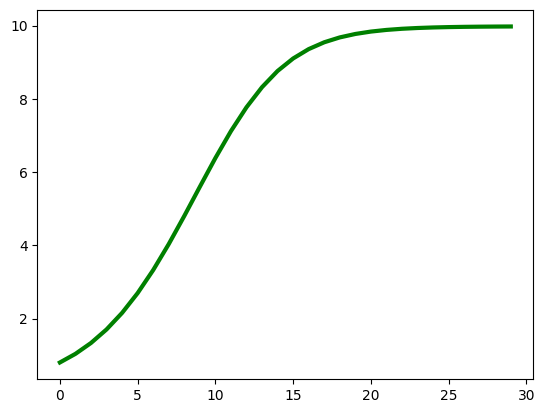

In [98]:
T = 30
#output_dist
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

Another property:

$$O_{[0, 10]} (H (x<10))$$

In [99]:
# Compute O_{[20,30]}(H(x<10))
# This means: there exists a point t in [20,30] such that historically (all points before t) are < 10

# For each trajectory and each time point t in [20,30], check if all values from 0 to t are < 10
property_holds_per_traj = torch.zeros(len(trajs), dtype=torch.bool)

for t in range(20, 31):  # timesteps 20 to 30 inclusive
    # Check if all values from 0 to t are < 10
    all_before_t_less_10 = torch.all(trajs[:, :t+1] < 10.0, dim=1)
    # Update: if this t satisfies, mark the trajectory
    property_holds_per_traj = property_holds_per_traj | all_before_t_less_10

# Probability: fraction of trajectories satisfying the property
prob_O_H_x10 = property_holds_per_traj.float().mean()

print(f"Property O_[20,30](H(x<10)):")
print(f"  (At least one point in [20,30] where historically x<10)")
print(f"  Number of trajectories: {len(trajs)}")
print(f"  Trajectories satisfying property: {property_holds_per_traj.sum().item()}")
print(f"  Probability: {prob_O_H_x10.item():.6f}")

#Calculate the 95% CI for this probability
n = len(trajs)
p = prob_O_H_x10.item()
se = np.sqrt(p * (1 - p) / n)
ci_lower = p - 1.96 * se
ci_upper = p + 1.96 * se
print(f"95% confidence interval for P(O_[20,30](H(x<10))): [{ci_lower:.4f}, {ci_upper:.4f}]")

#probability that the first 21 points of trajs are < 10
prob_first_21_less_10 = torch.all(trajs[:, :21] < 10.0, dim=1).float().mean()
print(f"P(all first 21 < 10) via MC: {prob_first_21_less_10.item():.6f}")

# DEGAS

prob_O_H_analytic = output_dist.gm.marg_cdf(torch.full((21,), 10.0), idx=list(range(0, 21)))
print(f"P(O_[20,30](H(x<10))) DEGAS: {prob_O_H_analytic.item():.6f}")


Property O_[20,30](H(x<10)):
  (At least one point in [20,30] where historically x<10)
  Number of trajectories: 10000
  Trajectories satisfying property: 4677
  Probability: 0.467700
95% confidence interval for P(O_[20,30](H(x<10))): [0.4579, 0.4775]
P(all first 21 < 10) via MC: 0.467700
P(O_[20,30](H(x<10))) DEGAS: 0.519279


In [100]:
compiledFile = compile2SOGA('logistic_MV_2.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

In [101]:
print(output_dist.gm.mean()[output_dist.var_list.index('OH')])

tensor(0.4699)


## PLOT

In [103]:
compiledFile = compile2SOGA('logistic.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)
output_dist = start_SOGA(cfg)

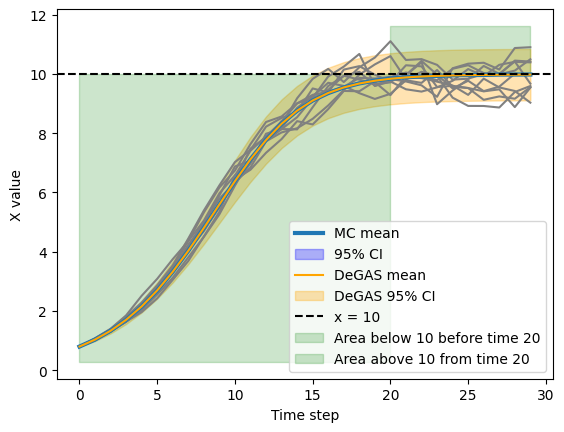

In [106]:
T = trajs.shape[1]
for i in range(10):
    plt.plot(range(T), trajs[i], color='grey')
plt.plot(range(T), torch.mean(trajs, 0), lw=3, label='MC mean')
col_var = trajs.var(dim=0)
col_mu = trajs.mean(dim=0) 
# add shaded area for 95% confidence interval
ci_lower_traj = col_mu - 1.96 * torch.sqrt(col_var / trajs.shape[0])
ci_upper_traj = col_mu + 1.96 * torch.sqrt(col_var / trajs.shape[0])
plt.fill_between(range(T), ci_lower_traj, ci_upper_traj, color='blue', alpha=0.3, label='95% CI')
# plot mean from SOGA
plt.plot(range(T), output_dist.gm.mean()[ list(range(0,30))], label='DeGAS mean', color='orange')
#plot standard deviation from SOGA as shaded area
soga_std = torch.sqrt(torch.diagonal(output_dist.gm.cov())[ list(range(0,30))])
soga_ci_lower = output_dist.gm.mean()[ list(range(0,30))] - 1.96 * soga_std
soga_ci_upper = output_dist.gm.mean()[ list(range(0,30))] + 1.96 * soga_std
plt.fill_between(range(T), soga_ci_lower, soga_ci_upper, color='orange', alpha=0.3, label='DeGAS 95% CI')

# horizontal threshold and green shading
plt.axhline(10, linestyle='--', color='black', label='x = 10')
ax = plt.gca()
ymin, ymax = ax.get_ylim()
plt.fill_between(range(0, 21), ymin, 10, color='green', alpha=0.2, label='Area below 10 before time 20')
plt.fill_between(range(20, T), 10, ymax, color='green', alpha=0.2, label='Area above 10 from time 20')

plt.legend()

plt.xlabel('Time step')
plt.ylabel('X value')
plt.show()

In [107]:
import os
import pandas as pd

# Create file_plots directory if it doesn't exist
os.makedirs('file_plots', exist_ok=True)

# Save individual trajectories with time index
trajs_df = pd.DataFrame()
trajs_df['time'] = range(T)
for i in range(10):
    trajs_df[f'traj_{i}'] = trajs[i].detach().numpy()
trajs_df.to_csv('file_plots/trajectories_logistic.csv', index=False)

# Save MC mean and CI
mc_data = pd.DataFrame({
    'time': range(T),
    'mc_mean': torch.mean(trajs, 0).detach().numpy(),
    'mc_ci_lower': ci_lower_traj.detach().numpy(),
    'mc_ci_upper': ci_upper_traj.detach().numpy()
})
mc_data.to_csv('file_plots/mc_mean_ci_logistic.csv', index=False)

# Save DeGAS mean and CI
soga_data = pd.DataFrame({
    'time': range(T),
    'soga_mean': output_dist.gm.mean()[list(range(0,30))].detach().numpy(),
    'soga_ci_lower': soga_ci_lower.detach().numpy(),
    'soga_ci_upper': soga_ci_upper.detach().numpy()
})
soga_data.to_csv('file_plots/soga_mean_ci_logistic.csv', index=False)

print("CSV files saved to file_plots/")
print(f"  - trajectories_logistic.csv (10 sample trajectories with time index)")
print(f"  - mc_mean_ci_logistic.csv (MC mean and 95% CI)")
print(f"  - soga_mean_ci_logistic.csv (DeGAS mean and 95% CI)")


CSV files saved to file_plots/
  - trajectories_logistic.csv (10 sample trajectories with time index)
  - mc_mean_ci_logistic.csv (MC mean and 95% CI)
  - soga_mean_ci_logistic.csv (DeGAS mean and 95% CI)
